# xcube

This notebook shows how to use xcube to query data from CDSE.

It is very similar to odc-stac. However it has gdal as a dependency, which makes the environment setup less straightforward. In particular on windows the easiest way to set up an environment with xcube is using conda or any of its alternatives (mamba, pixi). For this example I am using pixi.

In [29]:
import pickle
import os
import boto3
from xcube.core.store import new_data_store, get_data_store_params_schema
import dask
from dask.distributed import Client, WorkerPlugin

In [2]:
with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)

In [6]:
store_params = get_data_store_params_schema("stac-cdse-ardc")

In [4]:
session = boto3.Session(profile_name="creodias")
credentials = session.get_credentials()
frozen = credentials.get_frozen_credentials()

xcube_bands = ["B03", "B11", "SCL"]
store = new_data_store(
    "stac-cdse-ardc",
    key=frozen.access_key,
    secret=frozen.secret_key,
)

In [5]:
%%time
ds = store.open_data(
    data_id="sentinel-2-l2a",
    asset_names=xcube_bands,
    time_range=[str(p["start"]), str(p["end"])],
    bbox=p["box_3035"].bounds,
    crs="EPSG:3035",
    spatial_res=10,
    query={"eo:cloud_cover": {"lte": 80}},
)

CPU times: total: 49.7 s
Wall time: 3min 8s


xcube by default constructs a lazy datacube. For this we need to query the stac catalog during the cube instantiation. This makes the instantiation take longer compared to odc-stac.
The instantiation process does not seem to be very optimized, taking very long just to construct the dask call graph.

Since unlike odc-stac, xcube constructs a lazy dask datacube by default, it would also get the data multi-threaded by default.

In [ ]:
%%time
computed = ds.compute(scheduler="threads", num_workers=8)

c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\default\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\default\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\default\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\default\Lib\site-packages\dask\_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\defau

CPU times: total: 2min 47s
Wall time: 25min 1s


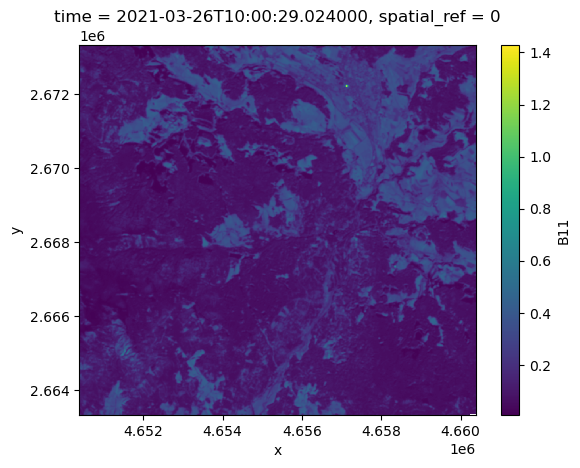

In [8]:
computed.B11.isel(time=22).plot();

This isn't that fast. Let's check if using multiple cores improves the situation.

In [16]:
class CDSEGdalEnv(WorkerPlugin):
    def __init__(self, env):
        self.env = env

    def setup(self, worker):
        os.environ.update(self.env)


client = Client(n_workers=8, threads_per_worker=4)
client.register_plugin(
    CDSEGdalEnv(
        {
            "AWS_S3_ENDPOINT": "eodata.dataspace.copernicus.eu",
            "AWS_VIRTUAL_HOSTING": "FALSE",
            "AWS_HTTPS": "YES",
            "AWS_DEFAULT_REGION": "default",
            "AWS_ACCESS_KEY_ID": frozen.access_key,
            "AWS_SECRET_ACCESS_KEY": frozen.secret_key,
        }
    )
)

c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\default\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 59915 instead
  warnings.warn(


{'tcp://127.0.0.1:59950': {'status': 'OK'},
 'tcp://127.0.0.1:59951': {'status': 'OK'},
 'tcp://127.0.0.1:59952': {'status': 'OK'},
 'tcp://127.0.0.1:59967': {'status': 'OK'},
 'tcp://127.0.0.1:59970': {'status': 'OK'},
 'tcp://127.0.0.1:59973': {'status': 'OK'},
 'tcp://127.0.0.1:59976': {'status': 'OK'},
 'tcp://127.0.0.1:59977': {'status': 'OK'}}

In [17]:
%%time
computed = ds.compute()

c:\Users\Jonas.Viehweger\Documents\Projects\2026\s2-time-series-access\xcube-nb\.pixi\envs\default\Lib\site-packages\distributed\client.py:3415: UserWarning: Sending large graph of size 11.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: total: 9.5 s
Wall time: 8min 47s


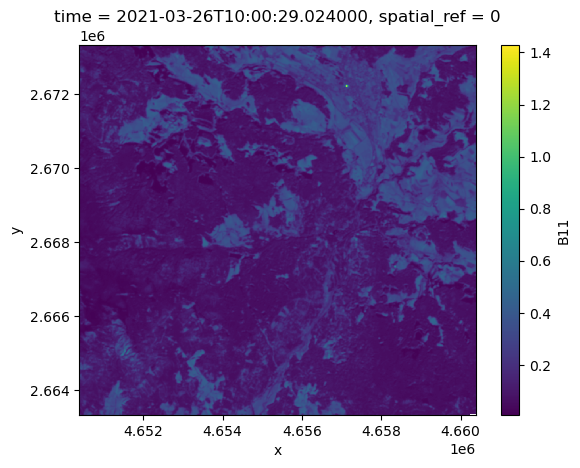

In [18]:
computed.B11.isel(time=22).plot();

No, this actually makes things worse. We also get a warning that we are sending a large call graph. However xcube has one last trick up its sleeve: There's an extra mode which gets data in the native UTM projection which should make everything more efficient.

This has a few restrictions: 

- Only square AOIs in UTM zones are possible. 
- AOIs crossing UTM zones are not possible. 
- The width and height are also restricted to 10 x 10 km.

Let's try it!

In [30]:
%%time
with dask.config.set(scheduler="threads", num_workers=32):
    utm_ds = store.open_data(
        data_id="sentinel-2-l2a",
        point=tuple(*p["point"].coords),
        bbox_width=10000,
        time_range=[str(p["start"]), str(p["end"])],
        spatial_res=10,
        asset_names=xcube_bands,
        query={"eo:cloud_cover": {"lte": 80}},
    )

CPU times: total: 1.84 s
Wall time: 25.3 s


The datacube is initialized twice as fast. Let's see if there's also an improvement when querying the data. However the main reason for that is that only 48 elements were queried. Which is about half as before.

I am unsure why that is, since our AOI is fully within a single Sentinel-2 tile. The same amount of data should be available to this query.

In [26]:
%%time
computed_utm = utm_ds.compute(scheduler="threads", num_workers=32)

CPU times: total: 1min 22s
Wall time: 17min 50s


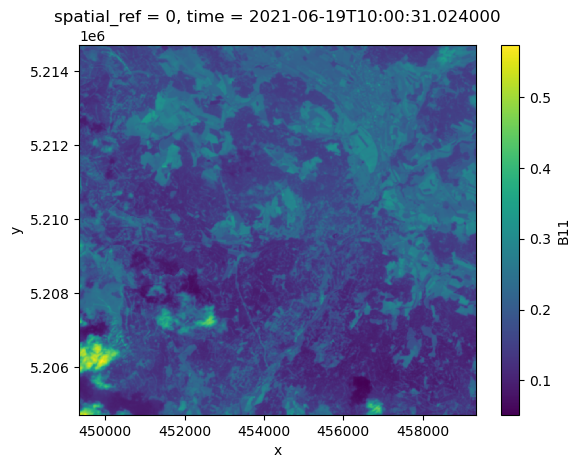

In [37]:
computed_utm.B11.isel(time=22).plot();